In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pathlib
import pickle
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
from scipy.stats import norm

import figure_config as fc
from figure_config import set_figure_config, one_column_width, two_column_width, COLOR_DEFAULT_BLUE, COLOR_DEFAULT_BLACK
from reverse_engineering.classes import CncDataTransformations, EvalConfig
from reverse_engineering.data_loading import DataAvailabilityScenarios
from reverse_engineering.plotting import plot_geometry_inner_shape
from reverse_engineering.protection import upsample_signals_to_original_index
from plotting_helpers import bake_alpha, gaussian_stats, plot_with_boundary_lines

In [3]:
set_figure_config()
default_arrow = dict(arrowstyle="-|>", linewidth=1, shrinkA=0, shrinkB=0, color=COLOR_DEFAULT_BLACK)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
sampling_rate_to_marker = {2: "x", 100: "+"}  #, 1000: "+"}
pad = 1.08
fig_no = 1
prefix = "contour_milling_"
folder = pathlib.Path("../results/")

In [10]:
with open(folder / f"{prefix}velocity_segmentation.pkl", "rb") as f:
    results_reversal_contour: dict[str, tuple[CncDataTransformations, EvalConfig]] = pickle.load(f)
with open(folder / f"{prefix}geometries.pkl", "rb") as f:
    results_geometries_contour = pickle.load(f)
with open(folder / f"{prefix}operating_states.pkl", "rb") as f:
    results_operating_states_contour = pickle.load(f)
with open(folder / f"{prefix}feeds.pkl", "rb") as f:
    results_feed_contour = pickle.load(f)
with open(folder / f"{prefix}radial_engagements.pkl", "rb") as f:
    results_radial_engagement_contour = pickle.load(f)
with open(folder / f"{prefix}features.pkl", "rb") as f:
    results_features_contour = pickle.load(f)
with open(folder / f"{prefix}state_monitoring_deviations.pkl", "rb") as f:
    results_sm_contour = pickle.load(f)
with open(folder / f"{prefix}predictive_quality_deviations.pkl", "rb") as f:
    results_pq_contour = pickle.load(f)

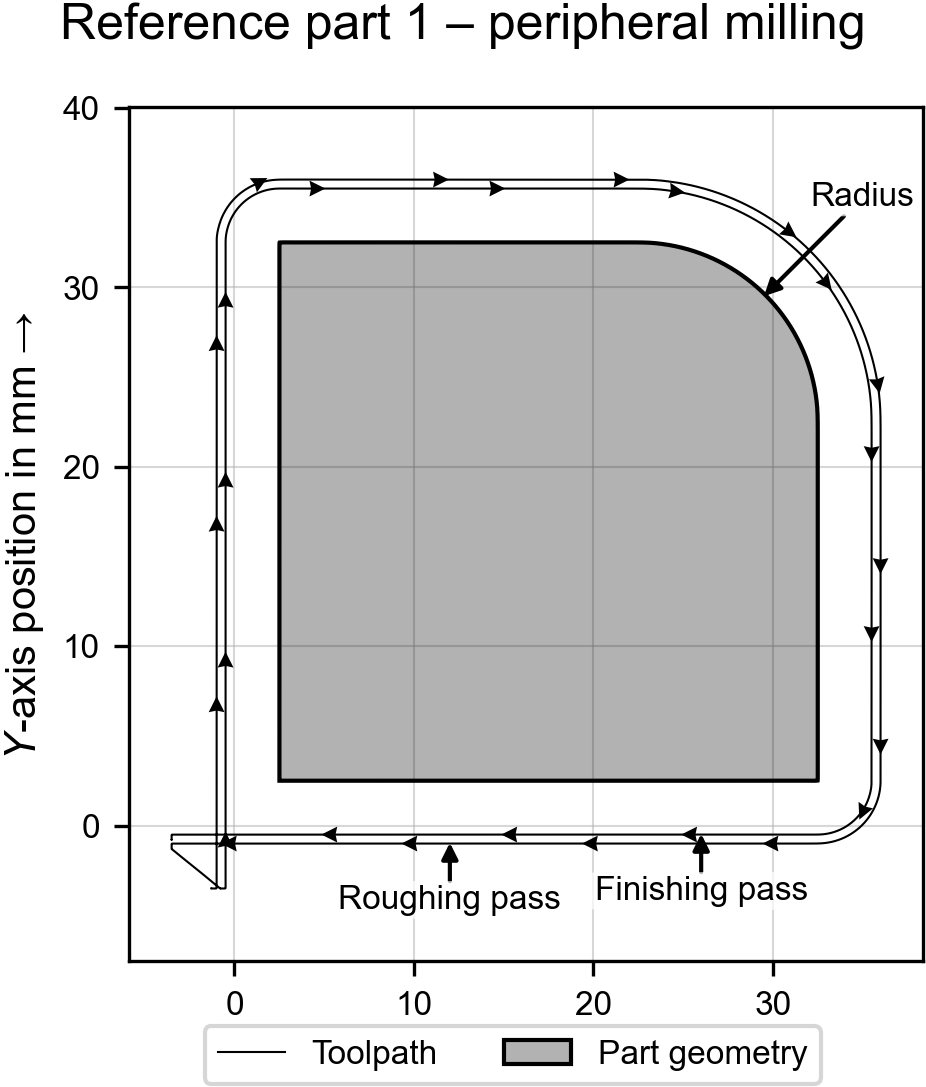

In [6]:
s = 16
jump = 10
tool_radius = 6
lw = 0.5

data, cfg = results_reversal_contour["ALL_ds_2_b_0.0_seed_0"]
union_true = results_geometries_contour.loc[("all", 2.0, 0.0), (0, "kalman")]

x_pos = data.original["x_pos_mm"]
y_pos = data.original["y_pos_mm"]

fig, ax = plt.subplots(1, 1, figsize=(one_column_width(), one_column_width() * 1.085))
plot_geometry_inner_shape(union_true, COLOR_DEFAULT_BLACK, ax, facecolor=to_rgba(COLOR_DEFAULT_BLACK, 0.3))
ax.plot(data.original["x_pos_mm"], data.original["y_pos_mm"], label="Toolpath", alpha=1.0, color=COLOR_DEFAULT_BLACK,
        linewidth=lw)

dx = (data.original["x_pos_mm"].diff())
dy = data.original["y_pos_mm"].diff()
length = np.linalg.norm(np.array([dx, dy]).T, axis=1)
feedrate = ((data.original["x_vel_mm_per_s"] ** 2 + data.original["y_vel_mm_per_s"] ** 2) ** 0.5)
length[feedrate < 3] = 0
dx = dx / length
dy = dy / length
n = 500
pts = list()
dist_min = 10
dist_acc = 0
row_prev = None
for idx, row in data.original.iterrows():
    if idx == data.original.index[0]:
        row_prev = row
        continue
    dist_acc += (((row["x_pos_mm"] - row_prev["x_pos_mm"]) ** 2 + (row["y_pos_mm"] - row_prev["y_pos_mm"]) ** 2) ** 0.5)
    if dist_acc >= dist_min:
        pts.append(idx)
        dist_acc = 0
    row_prev = row
ax.quiver(
    data.original.loc[pts, "x_pos_mm"], data.original.loc[pts, "y_pos_mm"],
    dx.loc[pts].values, dy[pts].values,
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.001,
    headlength=20,
    headaxislength=18,
    headwidth=20,
    color=COLOR_DEFAULT_BLACK,
    zorder=3,
)

ax.annotate("Radius",
            xy=(29.5, 29.5),
            xytext=(35, 35), va="center", ha="center",
            arrowprops={**default_arrow, "color": COLOR_DEFAULT_BLACK},
            bbox=dict(boxstyle="round,pad=0.1", fc="white", edgecolor="none", alpha=0.7))
ax.annotate(r"Roughing pass", xy=(12, -0.95), xytext=(12, -5), va="bottom",
            ha="center", color=COLOR_DEFAULT_BLACK,
            arrowprops={**default_arrow, "color": COLOR_DEFAULT_BLACK},
            bbox=dict(boxstyle="round,pad=0.1", fc="white", edgecolor="none", alpha=0.7))
ax.annotate(r"Finishing pass", xy=(26, -0.45), xytext=(26, -4.5), va="bottom",
            ha="center", color=COLOR_DEFAULT_BLACK, arrowprops={**default_arrow, "color": COLOR_DEFAULT_BLACK},
            bbox=dict(boxstyle="round,pad=0.1", fc="white", edgecolor="none", alpha=0.7))

ax.set_ylabel(r"$\it{Y}$-axis position in mm →")
ax.set_aspect("equal", "datalim")
ax.margins(0.06)

toolpath_arrow = FancyArrowPatch(
    (0, 0), (10, 0),
    arrowstyle=default_arrow,
    color=COLOR_DEFAULT_BLACK,
    linewidth=lw, shrinkA=0, shrinkB=0
)
toolpath_arrow.set_label("Toolpath")
legend_handles = [
    Line2D([0], [0], color=COLOR_DEFAULT_BLACK, linestyle="-", label="Toolpath", linewidth=lw),
    plt.Rectangle((0, 0), 0, 0, transform=ax.transAxes, label="Part geometry",
                  fc=to_rgba(COLOR_DEFAULT_BLACK, 0.3),
                  ec=COLOR_DEFAULT_BLACK, ),
]
fig.legend(
    handles=legend_handles,
    ncol=2,
    loc="lower center",
    bbox_to_anchor=(0.55, -0.04),
    frameon=True
)

fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(pad=pad, rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")
fig_no += 1

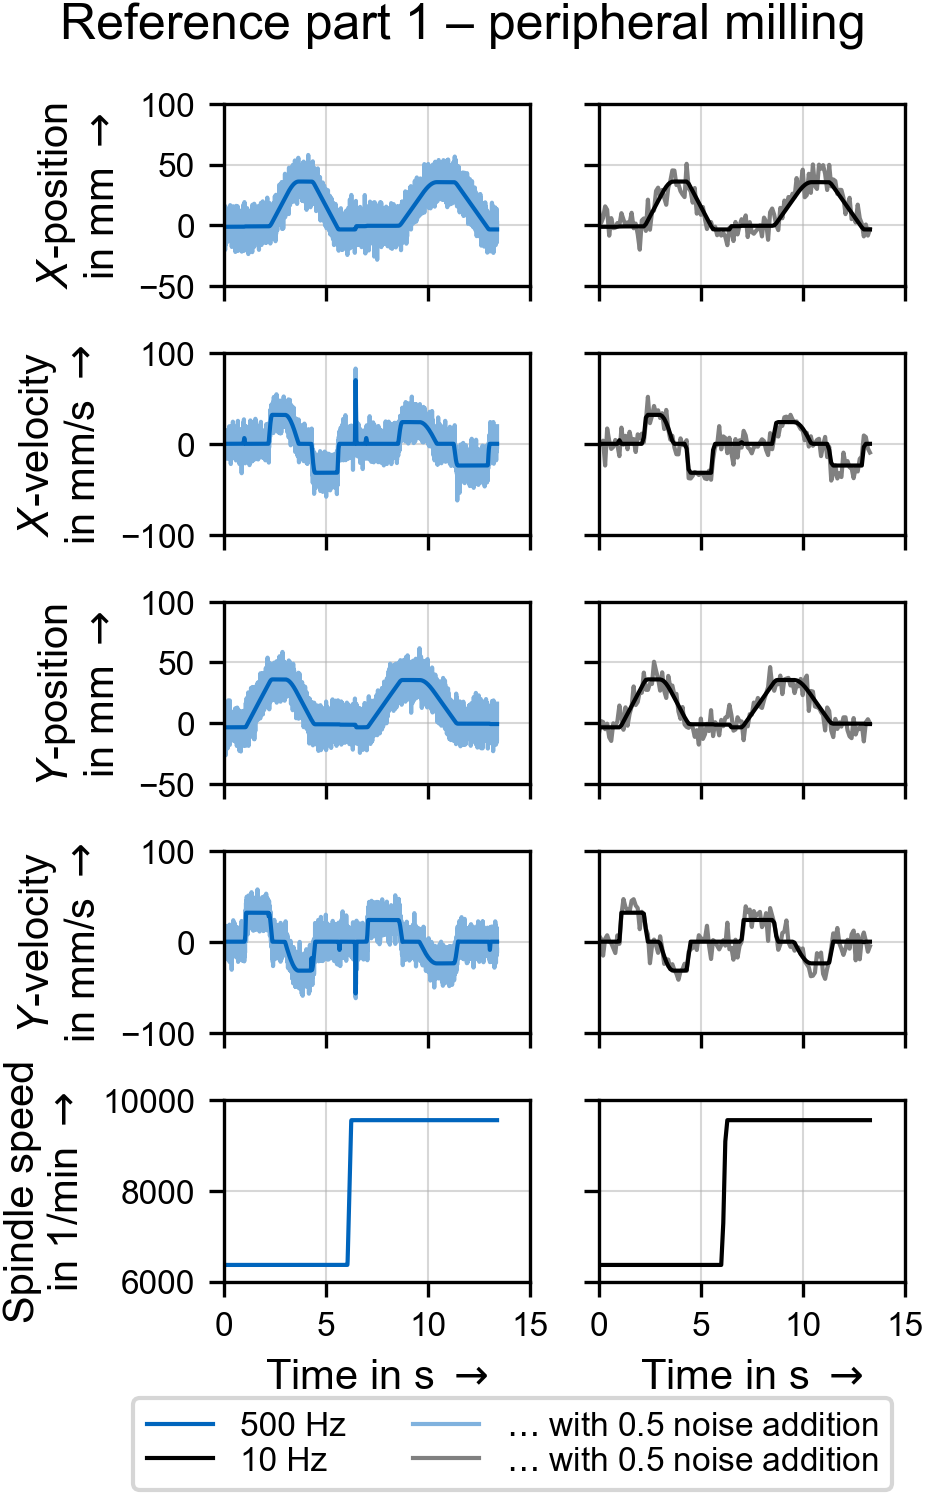

In [7]:
data_500_hz_contour, _ = results_reversal_contour["ALL_ds_2_b_0.5_seed_0"]
data_10_hz_contour, _ = results_reversal_contour["ALL_ds_100_b_0.5_seed_0"]

fig, ax = plt.subplots(5, 2, figsize=(one_column_width(), two_column_width() / 1.4), sharex=True, sharey="row")

COLOR_LIGHT_BLUE = bake_alpha(COLOR_DEFAULT_BLUE, alpha=0.5)
COLOR_LIGHT_GREY = bake_alpha(COLOR_DEFAULT_BLACK, alpha=0.5)
colors_normal = (COLOR_DEFAULT_BLUE, COLOR_DEFAULT_BLACK)
colors_downsampled = (COLOR_LIGHT_BLUE, COLOR_LIGHT_GREY)
for i, data in enumerate([data_500_hz_contour, data_10_hz_contour]):
    ax[0, i].plot(data.noisy.index.total_seconds(), data.noisy["x_pos_mm"], color=colors_downsampled[i],
                  linestyle="-")
    ax[2, i].plot(data.noisy.index.total_seconds(), data.noisy["y_pos_mm"], color=colors_downsampled[i],
                  linestyle="-")
    ax[1, i].plot(data.noisy.index.total_seconds(), data.noisy["x_vel_mm_per_s"], color=colors_downsampled[i],
                  linestyle="-")
    ax[3, i].plot(data.noisy.index.total_seconds(), data.noisy["y_vel_mm_per_s"], color=colors_downsampled[i],
                  linestyle="-")

    ax[0, i].plot(data.aggregated.index.total_seconds(), data.aggregated["x_pos_mm"],
                  color=colors_normal[i], linestyle="-")
    ax[2, i].plot(data.aggregated.index.total_seconds(), data.aggregated["y_pos_mm"],
                  color=colors_normal[i], linestyle="-")
    ax[1, i].plot(data.aggregated.index.total_seconds(), data.aggregated["x_vel_mm_per_s"],
                  color=colors_normal[i], linestyle="-")
    ax[3, i].plot(data.aggregated.index.total_seconds(), data.aggregated["y_vel_mm_per_s"],
                  color=colors_normal[i], linestyle="-")
    ax[4, i].plot(data.aggregated.index.total_seconds(), data.aggregated["s_vel_deg_per_s"] / 360 * 60,
                  color=colors_normal[i], linestyle="-")

ax[4, 0].set_xlabel("Time in s" r" $\rightarrow$")
ax[4, 1].set_xlabel("Time in s" r" $\rightarrow$")
ax[0, 0].set_ylabel("$\it{X}$-position\nin mm" r" $\rightarrow$")
ax[1, 0].set_ylabel("$\it{X}$-velocity\nin mm/s" r" $\rightarrow$")
ax[2, 0].set_ylabel("$\it{Y}$-position\nin mm" r" $\rightarrow$")
ax[3, 0].set_ylabel("$\it{Y}$-velocity\nin mm/s" r" $\rightarrow$")
ax[4, 0].set_ylabel("Spindle speed\nin 1/min" r" $\rightarrow$")
ax[0, 0].set_ylim(-50, 100)
ax[0, 0].set_yticks([-50, 0, 50, 100])
ax[1, 0].set_ylim(-100, 100)
ax[2, 0].set_ylim(-50, 100)
ax[2, 0].set_yticks([-50, 0, 50, 100])
ax[3, 0].set_ylim(-100, 100)
ax[4, 0].set_ylim(6e3, 10e3)

freq_handles = [
    Line2D([0], [0], color=COLOR_DEFAULT_BLUE, linestyle="-", label="500 Hz"),
    Line2D([0], [0], color=COLOR_DEFAULT_BLACK, linestyle="-", label="10 Hz"),
    Line2D([0], [0], color=COLOR_LIGHT_BLUE, linestyle="-", label=r"$\ldots$ with 0.5 noise addition"),
    Line2D([0], [0], color=COLOR_LIGHT_GREY, linestyle="-", label=r"$\ldots$ with 0.5 noise addition"),
]
fig.legend(
    handles=freq_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.035),
    frameon=True
)

fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")
fig_no += 1

In [8]:
seeds = list()
rates = list()
noise = list()
for name, (data, cfg) in results_reversal_contour.items():
    seeds.append(cfg.protection.random_state)
    rates.append(cfg.protection.downsampling_rate_ms)
    noise.append(cfg.protection.noise_standard_deviation_multiplier)
seeds = np.unique(seeds)
rates = np.unique(rates)
noises = np.unique(noise)
data_availability_scenarios = [DataAvailabilityScenarios.ALL.value, DataAvailabilityScenarios.POSITION.value,
                               DataAvailabilityScenarios.VELOCITY.value]

# Data utility

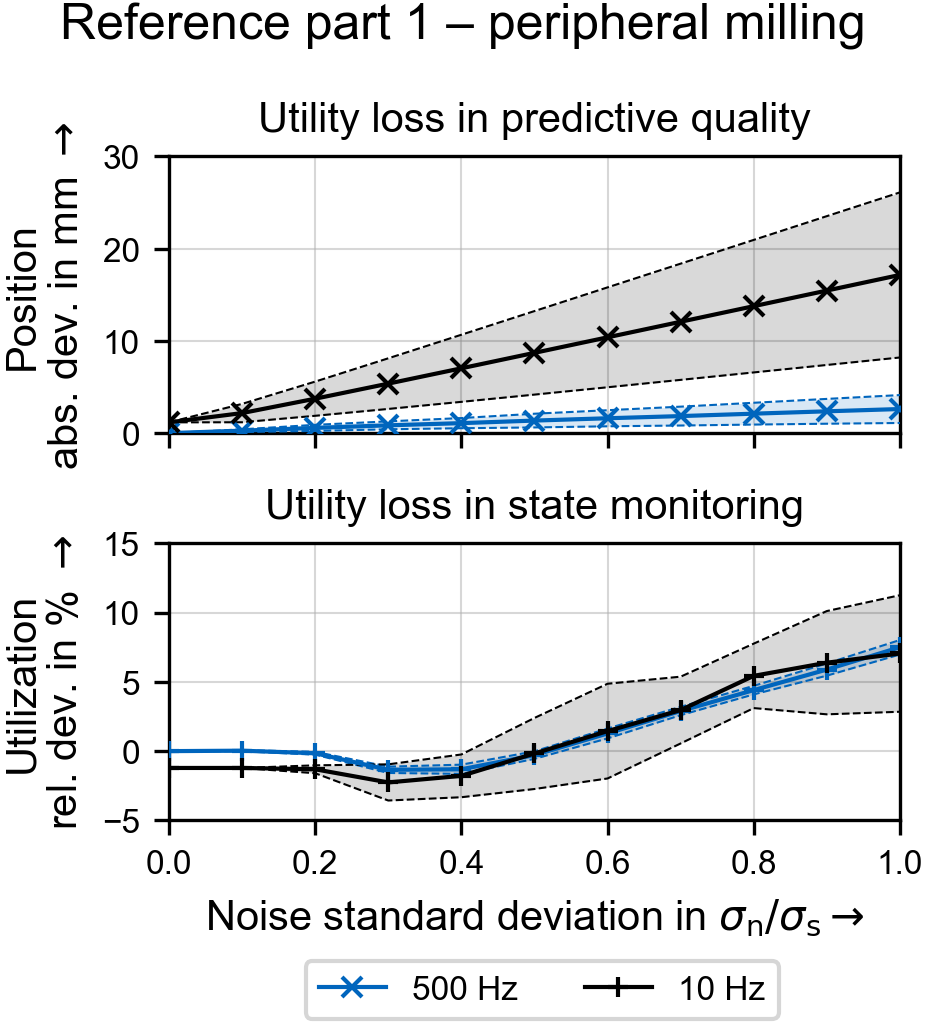

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(one_column_width(), one_column_width()), sharex=True)

scenario = "position"
for i, sampling_rate in enumerate(rates):
    distance_by_noise = defaultdict(list)
    for seed in seeds:
        series = results_pq_contour.loc[
            (scenario, sampling_rate, slice(None)), (seed, "none")]
        for idx, val in series.items():
            if val is not None:
                distance_by_noise[idx[2]].append(val)
    noises, mu, sigma = gaussian_stats(distance_by_noise)
    plot_with_boundary_lines(ax[0], noises, mu, sigma, f"C{i}", marker="x")

ax[0].set_xlim(0, 1)
ax[0].set_ylabel("Position\nabs. dev." r" in mm $\rightarrow$")
ax[0].set_title("Utility loss in predictive quality")

scenario = "velocity"
utilization_mean = results_sm_contour.T.groupby(level=1).mean().T * 100
utilization_original = utilization_mean.loc[("velocity", 2, 0.0), "none"]
for i, sampling_rate in enumerate(rates):
    utilization_by_noise = defaultdict(list)
    for seed in seeds:
        series = results_sm_contour.loc[
            (scenario, sampling_rate, slice(None)), (seed, "none")]
        for idx, val in series.items():
            if val is not None:
                utilization_by_noise[idx[2]].append((val * 100 - utilization_original) / utilization_original * 100)
    noises, mu, sigma = gaussian_stats(utilization_by_noise)
    plot_with_boundary_lines(ax[1], noises, mu, sigma, f"C{i}", marker="+")

ax[1].set_xlabel(r"Noise standard deviation in $\sigma_\text{n}/\sigma_\text{s} \rightarrow$")
ax[1].set_ylabel("Utilization\nrel. dev." r" in % $\rightarrow$")
ax[1].set_title("Utility loss in state monitoring")
fig.suptitle("Reference part 1 – peripheral milling")
time_handles = [
    Line2D([0], [0], color='C0', label="500 Hz", marker="x"),
    Line2D([0], [0], color='C1', label="10 Hz", marker="+"),
]
fig.legend(
    handles=time_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.58, 0.03),
    frameon=True,
)
fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(pad=pad, rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")
fig_no += 1

# Noise estimation

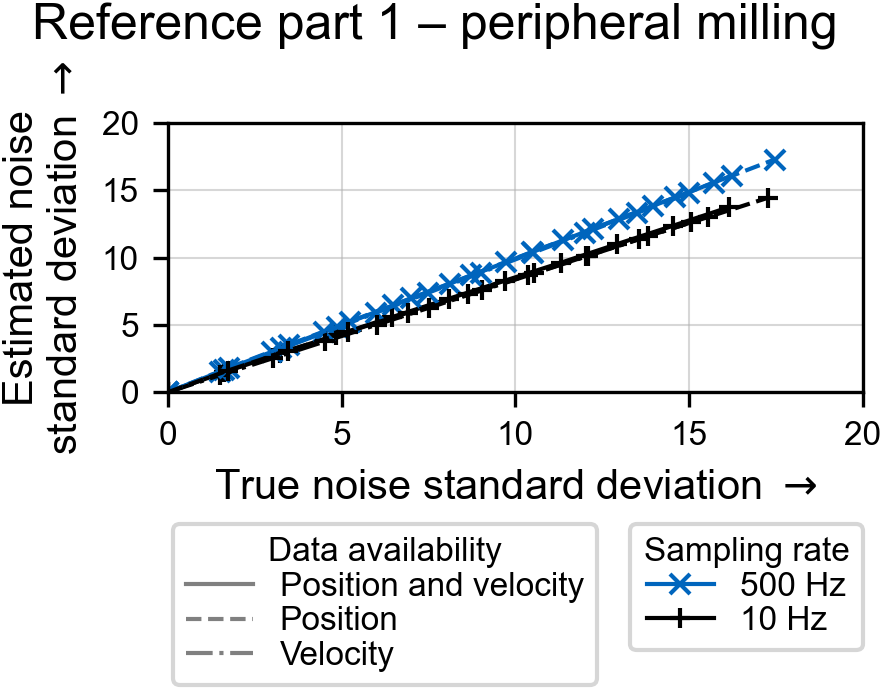

In [13]:
index = pd.MultiIndex.from_product([data_availability_scenarios, rates, noises],
                                   names=["Data availability", "Sampling rate", "Noise"])
columns = pd.MultiIndex.from_product([seeds, []], names=["Seed", "Signal"])
results_estimated_noise = pd.DataFrame(index=index, columns=columns)
results_true_noise = pd.DataFrame(index=index, columns=columns)
results_noise_diff = pd.DataFrame(index=index, columns=columns)
for name, (data, cfg) in results_reversal_contour.items():
    data: CncDataTransformations
    seed = cfg.protection.random_state
    rate = cfg.protection.downsampling_rate_ms
    data_availability = cfg.protection.data_availability_scenario.value
    noise = cfg.protection.noise_standard_deviation_multiplier

    for key in data.noise_est.keys():
        results_true_noise.loc[(data_availability, rate, noise), (seed, key)] = data.suppressed[
                                                                                    key].std() * cfg.protection.noise_standard_deviation_multiplier
        results_estimated_noise.loc[(data_availability, rate, noise), (seed, key)] = data.noise_est[key]
        results_noise_diff.loc[(data_availability, rate, noise), (seed, key)] = results_estimated_noise.loc[
                                                                                    (data_availability, rate, noise), (
                                                                                        seed, key)] - \
                                                                                results_true_noise.loc[
                                                                                    (data_availability, rate, noise), (
                                                                                        seed, key)]
results_noise_diff_dev_contour = results_noise_diff.T.mean().T
results_estimated_noise = results_estimated_noise.T.mean().T
results_true_noise = results_true_noise.T.mean().T
fig, ax = plt.subplots(sharey=True, sharex=True, figsize=(one_column_width(), one_column_width() / 1.8))

results = results_noise_diff_dev_contour
for i, ds_rate in enumerate(rates):
    true_values = results_true_noise.loc[("all", ds_rate, slice(None))].values
    estimated_values = results_estimated_noise.loc[("all", ds_rate, slice(None))].values
    ax.plot(true_values, estimated_values, label=f"Position and velocity at {ds_rate} ms",
            linestyle="-", color=f"C{i}", marker=sampling_rate_to_marker[ds_rate])
for i, ds_rate in enumerate(rates):
    true_values = results_true_noise.loc[("position", ds_rate, slice(None))].values
    estimated_values = results_estimated_noise.loc[("position", ds_rate, slice(None))].values
    ax.plot(true_values, estimated_values, label=f"Position at {ds_rate} ms",
            linestyle="-.", color=f"C{i}", marker=sampling_rate_to_marker[ds_rate])
for i, ds_rate in enumerate(rates):
    true_values = results_true_noise.loc[("velocity", ds_rate, slice(None))].values
    estimated_values = results_estimated_noise.loc[("velocity", ds_rate, slice(None))].values
    ax.plot(true_values, estimated_values, label=f"Velocity at {ds_rate} ms",
            linestyle="--", color=f"C{i}", marker=sampling_rate_to_marker[ds_rate])

# axes[0, 0].set_ylim(None, 30)
ax.set_xlabel(r"True noise standard deviation" r" $\rightarrow$")
ax.set_ylabel("Estimated noise\nstandard deviation" r" $\rightarrow$")
ax.set_xlim(0, 20)
ax.set_ylim(0, 20)

time_handles = [
    Line2D([0], [0], color='C0', label="500 Hz", marker="x"),
    Line2D([0], [0], color='C1', label="10 Hz", marker="+"),
]
quantity_handles = [
    Line2D([0], [0], color=fc.COLOR_GREY_50, linestyle='-', label='Position and velocity'),
    Line2D([0], [0], color=fc.COLOR_GREY_50, linestyle='--', label='Position'),
    Line2D([0], [0], color=fc.COLOR_GREY_50, linestyle='-.', label='Velocity'),
]
fig.legend(
    handles=time_handles,
    title="Sampling rate",
    ncol=1,
    loc="upper left",
    bbox_to_anchor=(0.68, 0.065),
    frameon=True,
)

fig.legend(
    handles=quantity_handles,
    title="Data availability",
    ncol=1,
    loc="upper right",
    bbox_to_anchor=(0.68, 0.065),
    frameon=True,
)
fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(pad=pad, rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")
fig_no += 1

# Data reversal

In [14]:
index = pd.MultiIndex.from_product([data_availability_scenarios, rates, noises],
                                   names=["Data availability", "Sampling rate", "Noise"])
columns = pd.MultiIndex.from_product([seeds, []], names=["Seed", "Method"])
results_position_deviation = pd.DataFrame(index=index, columns=columns)
results_velocity_deviation = pd.DataFrame(index=index, columns=columns)

for name, (data, cfg) in results_reversal_contour.items():
    seed = cfg.protection.random_state
    rate = cfg.protection.downsampling_rate_ms
    data_availability = cfg.protection.data_availability_scenario.value
    noise = cfg.protection.noise_standard_deviation_multiplier
    for method, df in data.reversed.items():
        df_upsampled = upsample_signals_to_original_index(df, data.original.index)
        orig_pos = data.original[["x_pos_mm", "y_pos_mm"]].to_numpy()
        rev_pos = df_upsampled[["x_pos_mm", "y_pos_mm"]].to_numpy()
        euclid_pos = np.linalg.norm(orig_pos - rev_pos, axis=1)
        results_position_deviation.loc[(data_availability, rate, noise), (seed, method)] = np.sqrt((euclid_pos**2).mean())

        orig_vel = data.original[["x_vel_mm_per_s", "y_vel_mm_per_s"]].to_numpy()
        rev_vel = df_upsampled[["x_vel_mm_per_s", "y_vel_mm_per_s"]].to_numpy()
        orig_fr = np.linalg.norm(orig_vel, axis=1)
        rev_fr = np.linalg.norm(rev_vel, axis=1)
        euclid_vel = orig_fr - rev_fr
        results_velocity_deviation.loc[(data_availability, rate, noise), (seed, method)] = np.sqrt((euclid_vel**2).mean())

results_position_deviation_agg_seed = results_position_deviation.T.groupby(level=1).mean().T
results_velocity_deviation_agg_seed = results_velocity_deviation.T.groupby(level=1).mean().T

In [15]:
results_position_deviation_agg_seed.drop(["butter", "spline", "savgol"], axis=1, inplace=True)
results_velocity_deviation_agg_seed.drop(["butter", "spline", "savgol"], axis=1, inplace=True)

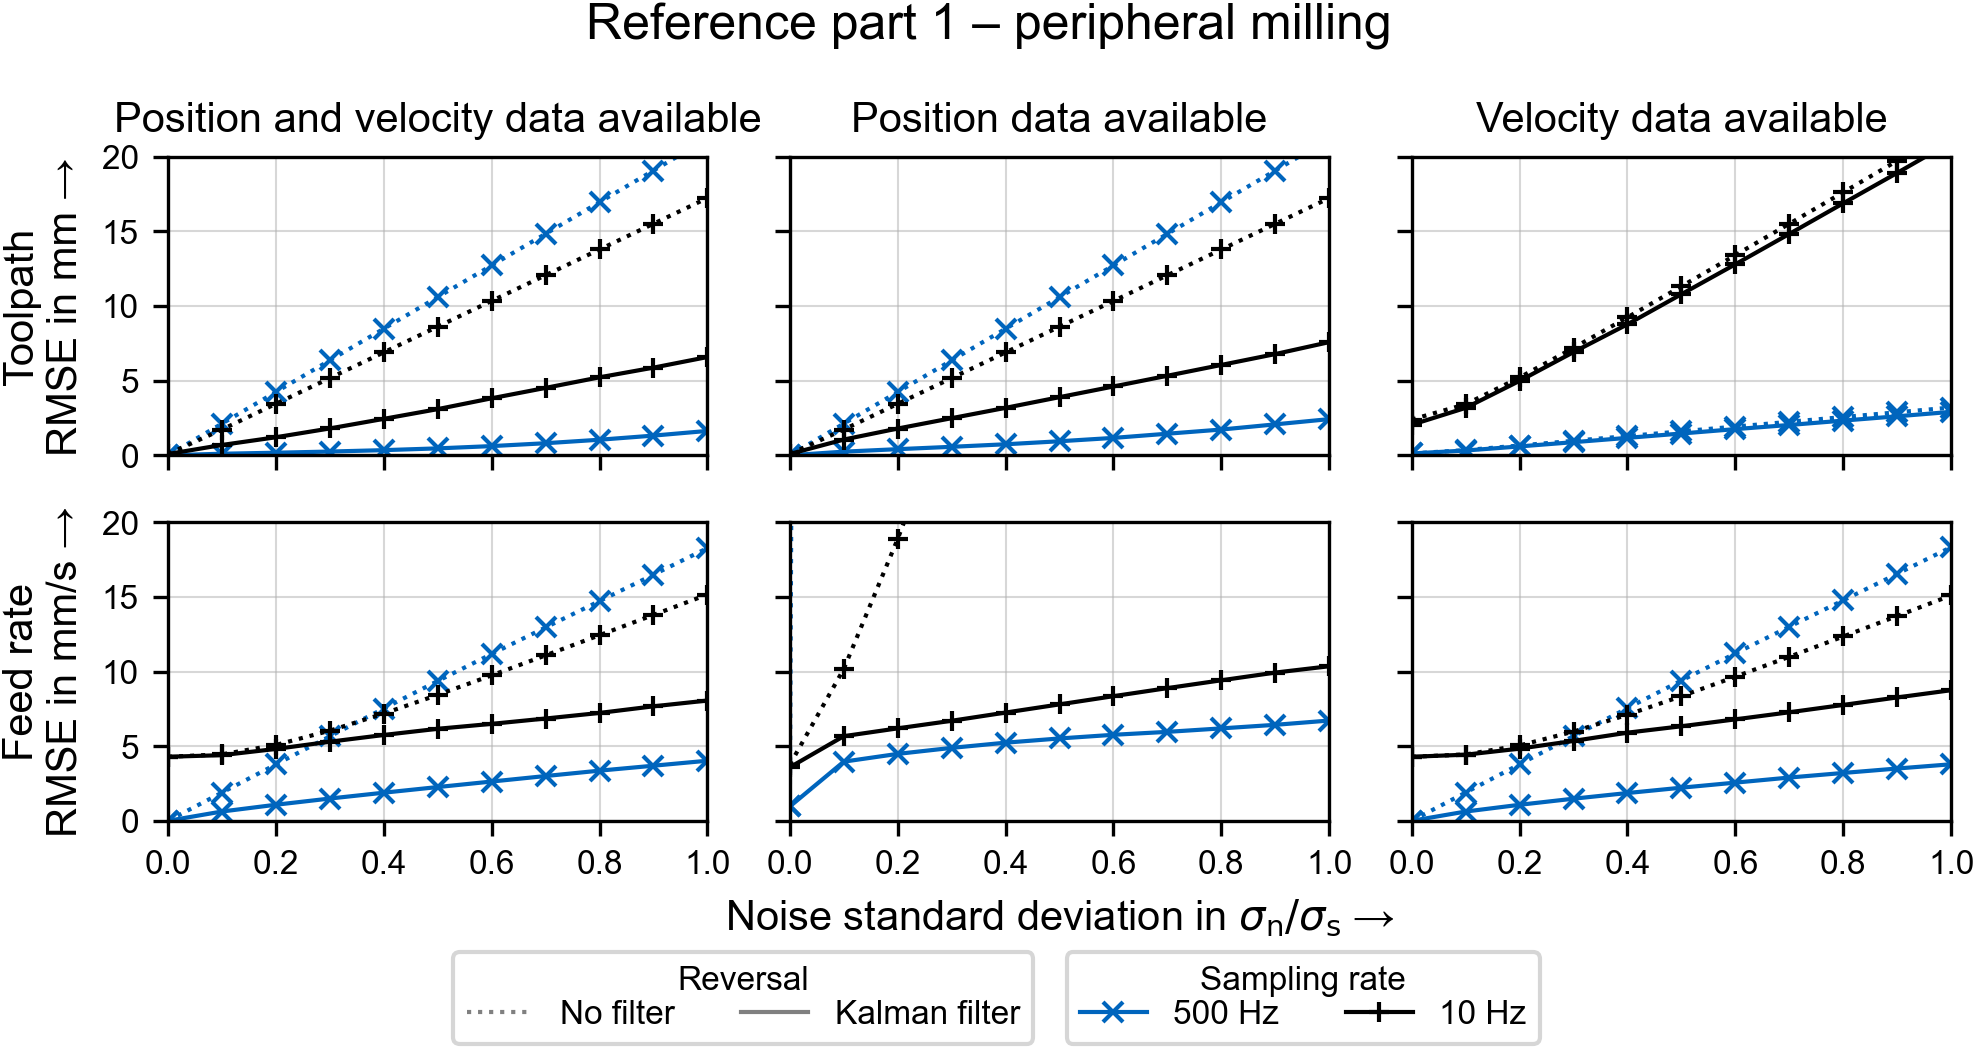

In [16]:
fig, axes = plt.subplots(2, 3, sharey="row", sharex=True, figsize=(two_column_width(), one_column_width()))
method_to_linestyle = {"none": ":", "kalman": "-", "butter": "--", "spline": "-.", "savgol": (0, (5, 10))}
# sampling_rate_to_marker = {2: "", 100: ""}
ax = axes[0, 0]
ax.set_title("Position and velocity data available")
for i, ds_rate in enumerate(rates):
    for method in results_position_deviation_agg_seed.columns:
        series = results_position_deviation_agg_seed.loc[("all", ds_rate, slice(None)), method]
        ax.plot(series.index.get_level_values(2), series.values, color=f"C{i}", marker=sampling_rate_to_marker[ds_rate], linestyle=method_to_linestyle[method])
ax = axes[0, 1]
ax.set_title("Position data available")
for i, ds_rate in enumerate(rates):
    for method in results_position_deviation_agg_seed.columns:
        series = results_position_deviation_agg_seed.loc[("position", ds_rate, slice(None)), method]
        ax.plot(series.index.get_level_values(2), series.values, color=f"C{i}", marker=sampling_rate_to_marker[ds_rate], linestyle=method_to_linestyle[method])
ax = axes[0, 2]
ax.set_title("Velocity data available")
for i, ds_rate in enumerate(rates):
    for method in results_position_deviation_agg_seed.columns:
        series = results_position_deviation_agg_seed.loc[("velocity", ds_rate, slice(None)), method]
        ax.plot(series.index.get_level_values(2), series.values, color=f"C{i}", marker=sampling_rate_to_marker[ds_rate], linestyle=method_to_linestyle[method])

ax = axes[1, 0]
for i, ds_rate in enumerate(rates):
    for method in results_velocity_deviation_agg_seed.columns:
        series = results_velocity_deviation_agg_seed.loc[("all", ds_rate, slice(None)), method]
        ax.plot(series.index.get_level_values(2), series.values, color=f"C{i}", marker=sampling_rate_to_marker[ds_rate], linestyle=method_to_linestyle[method])
ax = axes[1, 1]
for i, ds_rate in enumerate(rates):
    for method in results_velocity_deviation_agg_seed.columns:
        series = results_velocity_deviation_agg_seed.loc[("position", ds_rate, slice(None)), method]
        ax.plot(series.index.get_level_values(2), series.values, color=f"C{i}", marker=sampling_rate_to_marker[ds_rate], linestyle=method_to_linestyle[method])

ax = axes[1, 2]
for i, ds_rate in enumerate(rates):
    for method in results_velocity_deviation_agg_seed.columns:
        series = results_velocity_deviation_agg_seed.loc[("velocity", ds_rate, slice(None)), method]
        ax.plot(series.index.get_level_values(2), series.values, color=f"C{i}", marker=sampling_rate_to_marker[ds_rate], linestyle=method_to_linestyle[method])

axes[1, 1].set_xlabel(r"Noise standard deviation in $\sigma_\text{n}/\sigma_\text{s}$ →")
axes[0, 0].set_ylabel("Toolpath\nRMSE in mm →")
axes[1, 0].set_ylabel("Feed rate\nRMSE in mm/s →")
axes[0, 0].set_xlim(0, 1)
for ax in axes.flatten():
    ax.set_ylim(0, 20)
    ax.set_yticks(np.arange(0, 21, 5))

time_handles = [
    Line2D([0], [0], color='C0', label="500 Hz", marker="x"),
    Line2D([0], [0], color='C1', label="10 Hz", marker="+"),
]
fig.legend(
    handles=time_handles,
    title="Sampling rate",
    ncol=2,
    loc="upper left",
    bbox_to_anchor=(0.53, 0.04),
    frameon=True
)
quantity_handles = [
    Line2D([0], [0], color=fc.COLOR_GREY_50, linestyle=method_to_linestyle["none"], label='No filter'),
    Line2D([0], [0], color=fc.COLOR_GREY_50, linestyle=method_to_linestyle["kalman"], label='Kalman filter'),
]
fig.legend(
    handles=quantity_handles,
    title="Reversal",
    ncol=2,
    loc="upper right",
    bbox_to_anchor=(0.53, 0.04),
    frameon=True
)

fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(pad=pad, rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")
fig_no += 1

# Feeds, ae and geometric features

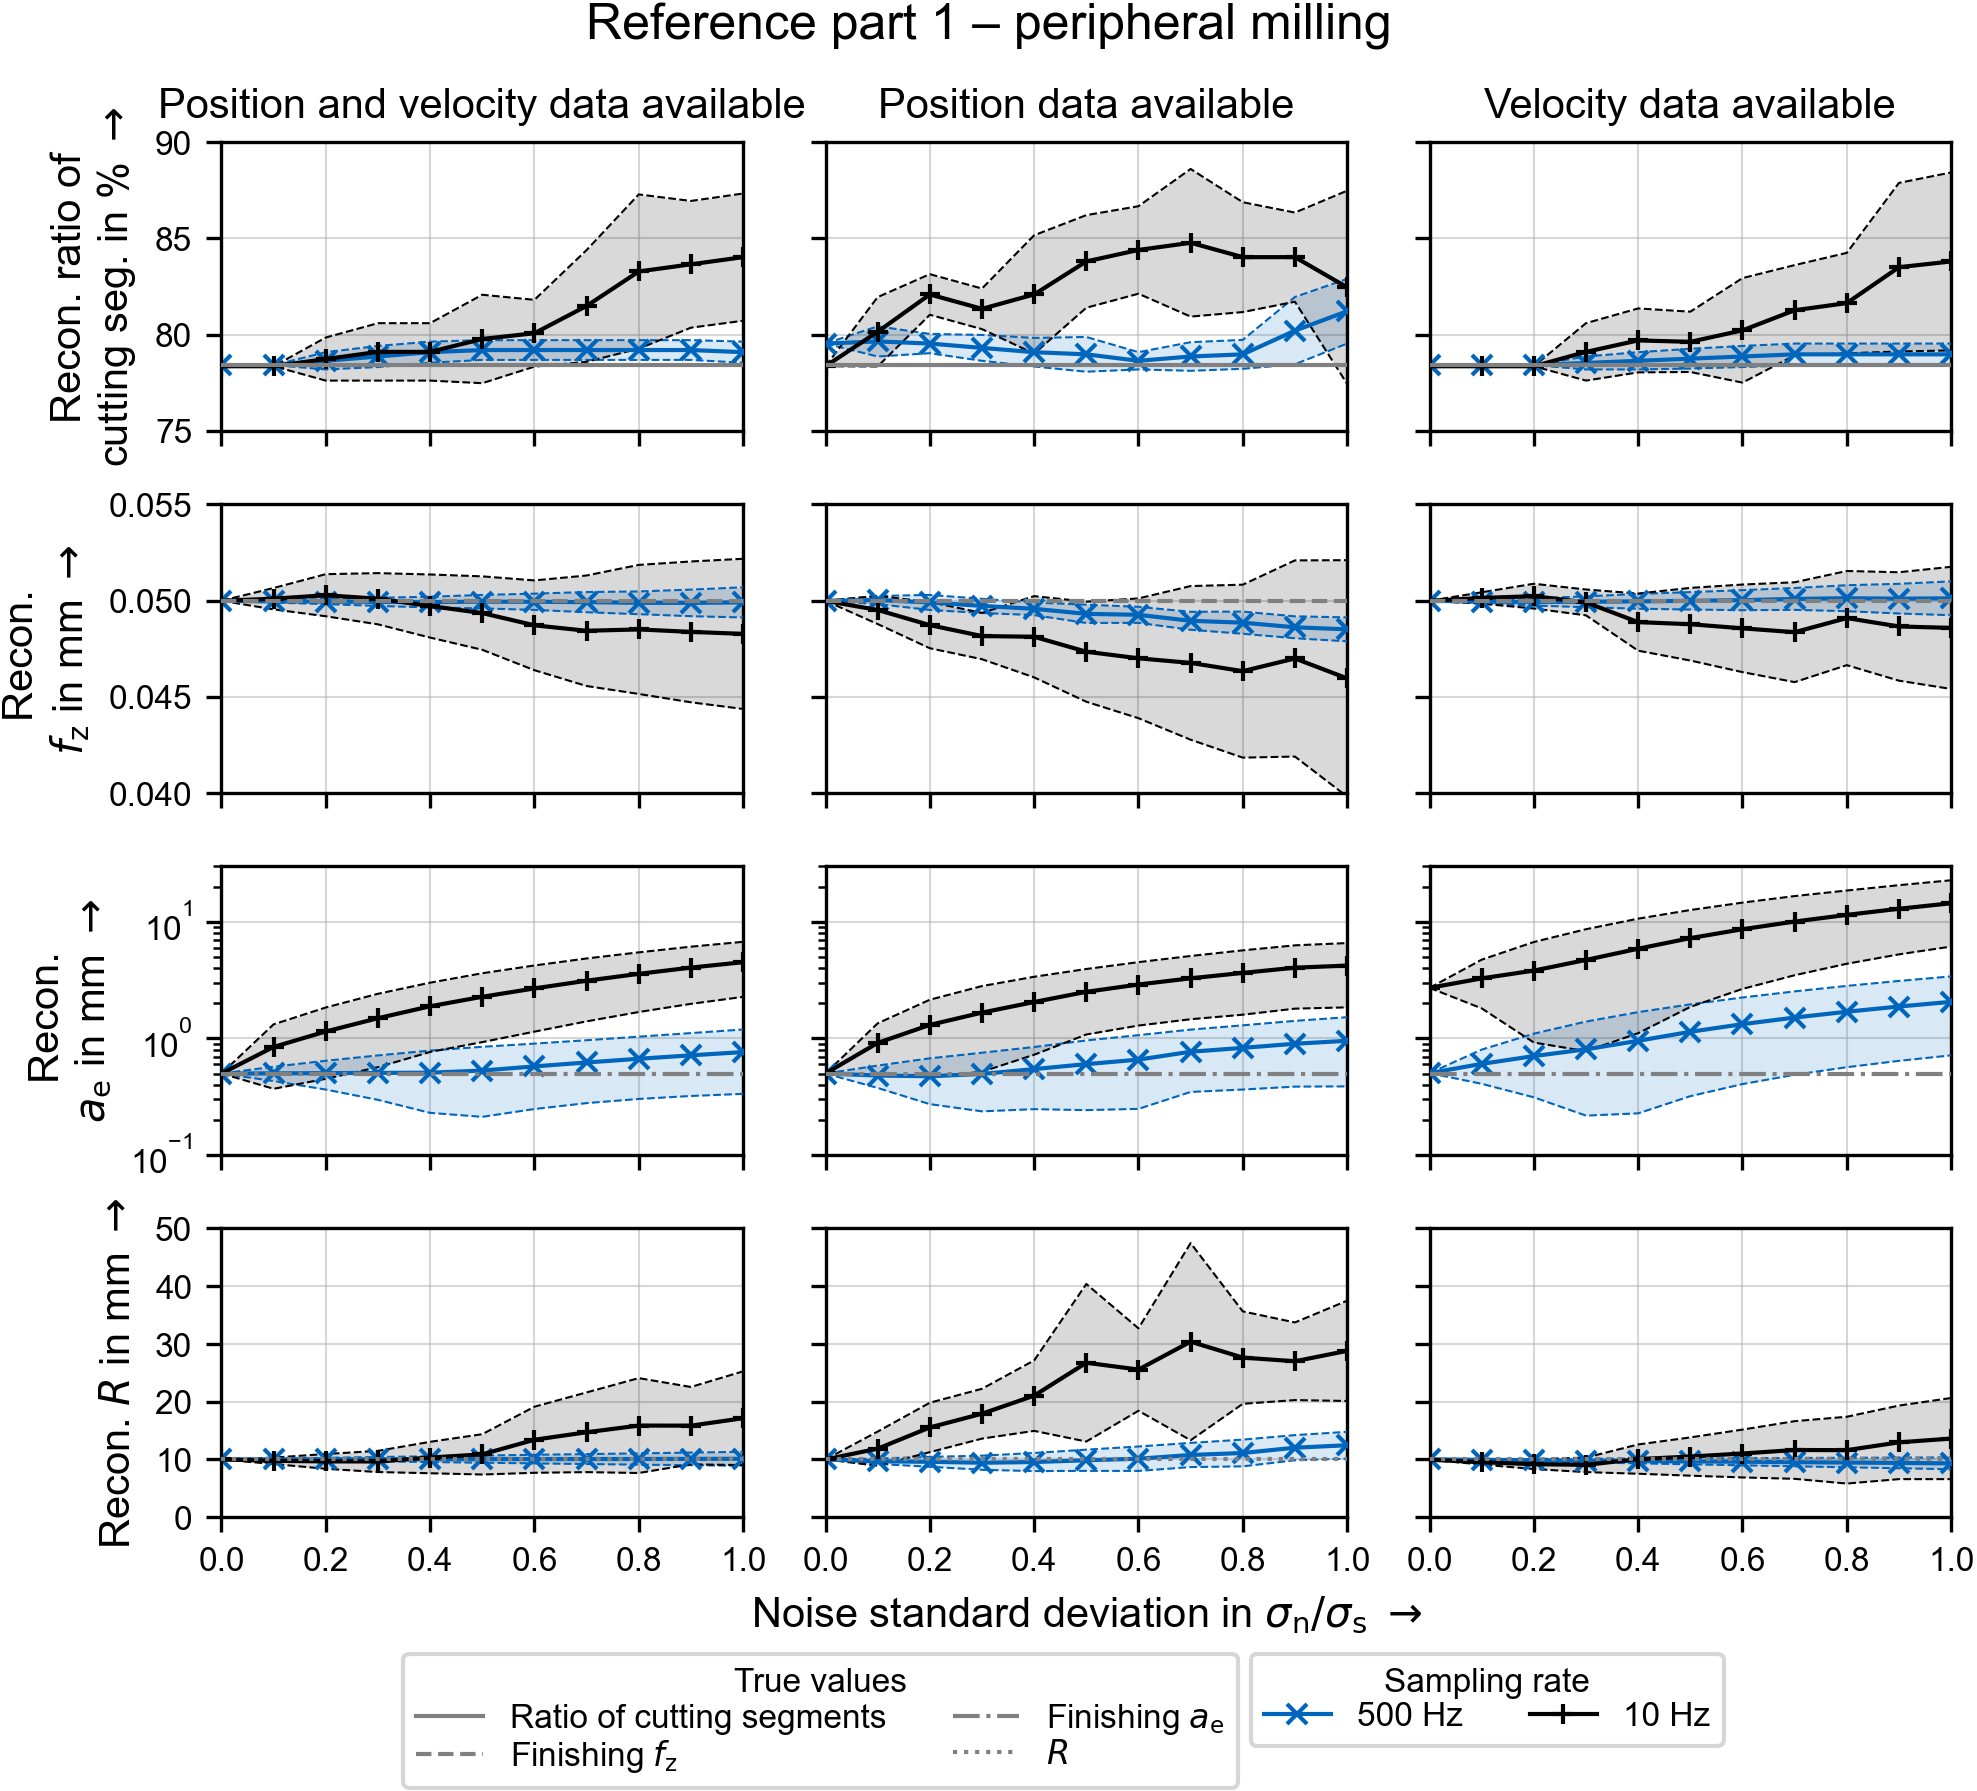

In [17]:
s = 15
feed_finishing = 0.05
radial_engagement_finishing = 0.5
tool_radius = 3.0
radius_true = 10.0

fig, ax = plt.subplots(4, 3, figsize=(two_column_width(), two_column_width() / 1.2), sharex=True, sharey="row")
scenario_to_title = {"all": "Position and velocity data available", "position": "Position data available",
                     "velocity": "Velocity data available"}

results_operating_states_contour_true = results_operating_states_contour.loc[("all", 2.0, 0.0), (0, "kalman")]
for j, scenario in enumerate(("all", "position", "velocity")):
    for i, sampling_rate in enumerate(rates):
        g1_by_noise = defaultdict(list)
        g0_by_noise = defaultdict(list)
        for seed in seeds:
            sub_df = results_operating_states_contour.loc[(scenario, sampling_rate, slice(None)), ([seed], "kalman")]
            for idx, row in sub_df.iterrows():
                noise_level = idx[2]
                for _, row_2 in row.items():
                    if not isinstance(row_2, (list, tuple, np.ndarray)):
                        continue
                    g1_by_noise[noise_level].append(row_2[1]*100)
                    g0_by_noise[noise_level].append(row_2[2]*100)

        noises, mu, sigma = gaussian_stats(g1_by_noise)
        plot_with_boundary_lines(ax[0, j], noises, mu, sigma, f"C{i}", marker=sampling_rate_to_marker[sampling_rate])
    ax[0, j].axhline(results_operating_states_contour_true[1]*100, color=fc.COLOR_GREY_50, linestyle="-", zorder=6)
    ax[0, j].set_ylim(75, 90)
    ax[0, j].set_title(scenario_to_title[scenario])
ax[0, 0].set_ylabel("Recon. ratio of\n" r"cutting seg. in %" r" $\rightarrow$")

for j, scenario in enumerate(("all", "position", "velocity")):
    for i, sampling_rate in enumerate(rates):
        feeds_by_noise = defaultdict(list)
        for seed in seeds:
            sub_df = results_feed_contour.loc[(scenario, sampling_rate, slice(None)), ([seed], "kalman")]
            for idx, row in sub_df.iterrows():
                noise_level = idx[2]
                for _, row_2 in row.items():
                    if not isinstance(row_2, (list, tuple, np.ndarray)):
                        continue
                    for segment in row_2:
                        if segment.start_loc < pd.Timedelta("6.5s"):
                            continue
                        if segment.feed is None:
                            continue
                        feeds_by_noise[noise_level].append(segment.feed)

        noises, mu, sigma = gaussian_stats(feeds_by_noise)
        plot_with_boundary_lines(ax[1, j], noises, mu, sigma, f"C{i}", marker=sampling_rate_to_marker[sampling_rate])
    ax[1, j].axhline(feed_finishing, color=fc.COLOR_GREY_50, linestyle="--", zorder=6)
    ax[1, j].set_yticks(np.arange(0.04, 0.56, 0.005))
    ax[1, j].set_ylim(0.04, 0.055)
ax[1, 0].set_ylabel("Recon. \n" r"$f_\text{z}$ in mm" r" $\rightarrow$")

for j, scenario in enumerate(("all", "position", "velocity")):
    for i, sampling_rate in enumerate(rates):
        ae_by_noise = defaultdict(list)
        for seed in results_radial_engagement_contour.columns.get_level_values(0).unique():
            series = results_radial_engagement_contour.loc[
                (scenario, sampling_rate, slice(None)), (seed, "kalman")]
            for idx, val in series.items():
                if isinstance(val, list):
                    ae_by_noise[idx[2]].append(abs(val[0]))
        noises, mu, sigma = gaussian_stats(ae_by_noise)
        plot_with_boundary_lines(ax[2, j], noises, mu, sigma, f"C{i}", marker=sampling_rate_to_marker[sampling_rate])
    ax[2, j].axhline(radial_engagement_finishing, color=fc.COLOR_GREY_50, linestyle="-.", zorder=6)
    ax[2, j].set_xlim(-0.05, 1.05)
    ax[2, j].semilogy()
    ax[2, j].set_ylim(1e-1, 30)
ax[2, 0].set_ylabel("Recon. \n" + r"$a_\text{e}$ in mm" r" $\rightarrow$")

for j, scenario in enumerate(("all", "position", "velocity")):
    for i, sampling_rate in enumerate(rates):
        radius_by_noise = defaultdict(list)
        for seed in results_features_contour.columns.get_level_values(0):
            series = results_features_contour.loc[(scenario, sampling_rate, slice(None)), (seed, "kalman")]
            for idx, val in series.items():
                if isinstance(val, list):
                    radius_by_noise[idx[2]].append(abs(val[0]) - tool_radius)
        noises, mu, sigma = gaussian_stats(radius_by_noise)
        plot_with_boundary_lines(ax[3, j], noises, mu, sigma, f"C{i}", marker=sampling_rate_to_marker[sampling_rate])
    ax[3, j].axhline(radius_true, color=fc.COLOR_GREY_50, linestyle=":", zorder=6)
    ax[3, j].set_yticks(np.arange(0, 51, 10))
    ax[3, j].set_ylim(0, 50)
ax[3, 0].set_ylabel("Recon. $R$ in mm" r" $\rightarrow$")

ax[3, 1].set_xlabel(r"Noise standard deviation in $\sigma_\text{n}/\sigma_\text{s}$" r" $\rightarrow$")
ax[0, 0].set_xlim(0, 1)

time_handles = [
    Line2D([0], [0], color='C0', label="500 Hz", marker="x"),
    Line2D([0], [0], color='C1', label="10 Hz", marker="+"),
]
fig.legend(handles=time_handles, ncol=len(rates), title="Sampling rate",
           loc="upper left", bbox_to_anchor=(0.62, 0.02), frameon=True)
param_handles = [
    Line2D([0], [0], color=fc.COLOR_GREY_50, label=r"Ratio of cutting segments", linestyle="-"),
    Line2D([0], [0], color=fc.COLOR_GREY_50, label=r"Finishing $f_\text{z}$", linestyle="--"),
    Line2D([0], [0], color=fc.COLOR_GREY_50, label=r"Finishing $a_\text{e}$", linestyle="-."),
    Line2D([0], [0], color=fc.COLOR_GREY_50, label=r"$R$", linestyle=":"),
]
fig.legend(handles=param_handles, ncol=2, title="True values",
           loc="upper right", bbox_to_anchor=(0.63, 0.02), frameon=True)

fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(pad=pad, rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")
fig_no += 1

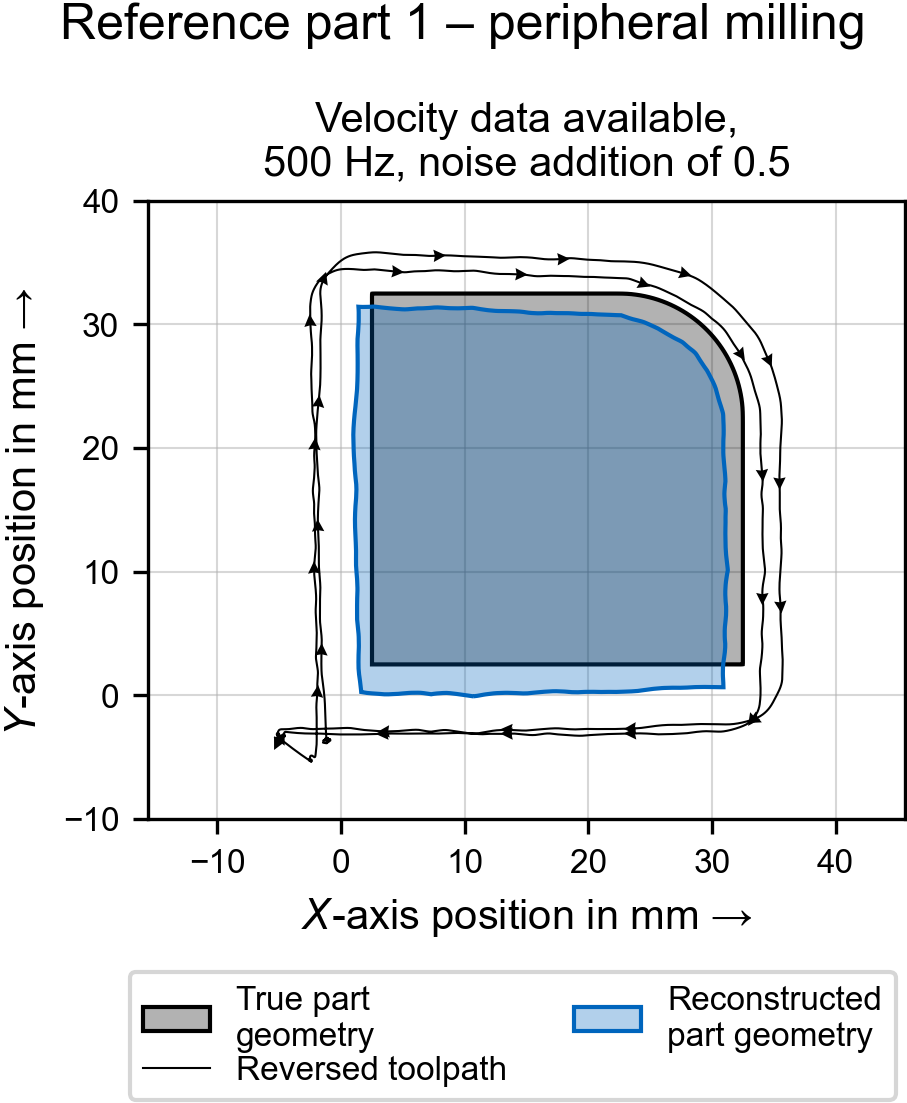

In [18]:
dist_min = 10
method = "kalman"

union_true = results_geometries_contour.loc[("all", 2.0, 0.0), (0, method)]
fig, ax = plt.subplots(1, 1, sharex=True, figsize=(one_column_width(), one_column_width()))

plot_geometry_inner_shape(union_true, COLOR_DEFAULT_BLACK, ax, facecolor=to_rgba(COLOR_DEFAULT_BLACK, 0.3))
union_position = results_geometries_contour.loc[("velocity", 2.0, 0.5), (0, method)]
plot_geometry_inner_shape(union_position, COLOR_DEFAULT_BLUE, ax)
data, cfg = results_reversal_contour["VELOCITY_ds_2_b_0.5_seed_0"]
ax.plot(data.reversed[method]["x_pos_mm"], data.reversed[method]["y_pos_mm"], label="Toolpath", alpha=1.0, color=COLOR_DEFAULT_BLACK,
        linewidth=lw)
dx = data.reversed[method]["x_pos_mm"].diff()
dy = data.reversed[method]["y_pos_mm"].diff()
length = np.linalg.norm(np.array([dx, dy]).T, axis=1)
feedrate = ((data.reversed[method]["x_vel_mm_per_s"] ** 2 + data.reversed[method]["y_vel_mm_per_s"] ** 2) ** 0.5)
dx = dx / length
dy = dy / length
pts = list()
dist_acc = 0
row_prev = None
for idx, row in data.reversed[method].iterrows():
    if idx == data.reversed[method].index[0]:
        row_prev = row
        continue
    dist_acc += (((row["x_pos_mm"] - row_prev["x_pos_mm"]) ** 2 + (row["y_pos_mm"] - row_prev["y_pos_mm"]) ** 2) ** 0.5)
    if dist_acc >= dist_min:
        pts.append(idx)
        dist_acc = 0
    row_prev = row
ax.quiver(
    data.reversed[method].loc[pts, "x_pos_mm"], data.reversed[method].loc[pts, "y_pos_mm"],
    dx.loc[pts].values, dy[pts].values,
    angles='xy',
    scale_units='xy',
    scale=1,
    width=0.001,
    headlength=20,
    headaxislength=18,
    headwidth=20,
    color=COLOR_DEFAULT_BLACK,
    zorder=3,
)
ax.set_title("Velocity data available,\n500 Hz, noise addition of 0.5")

ax.set_aspect("equal", 'datalim', share=True)
ax.set_xlabel(r"$\it{X}$-axis position in mm →")
ax.set_ylabel(r"$\it{Y}$-axis position in mm →")

freq_handles = [
    plt.Rectangle((0, 0), 0, 0, transform=ax.transAxes, label="True part\ngeometry",
                  fc=to_rgba(COLOR_DEFAULT_BLACK, 0.3),
                  ec=COLOR_DEFAULT_BLACK, ),
    Line2D([0], [0], color=COLOR_DEFAULT_BLACK, linestyle="-", label="Reversed toolpath", linewidth=lw),
    plt.Rectangle((0, 0), 0, 0, transform=ax.transAxes, label="Reconstructed\npart geometry",
                  fc=to_rgba(COLOR_DEFAULT_BLUE, 0.3),
                  ec=COLOR_DEFAULT_BLUE, ),
]
fig.legend(
    handles=freq_handles,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.02),
    frameon=True
)

fig.suptitle("Reference part 1 – peripheral milling")
fig.tight_layout(pad=pad, rect=[0, 0, 1, 1])
fig.savefig(f"plots/Fig{fig_no}.pdf")